In [ ]:
# Install / upgrade all required packages
!pip install -q --upgrade sympy
!pip install -q torch torchvision --extra-index-url https://download.pytorch.org/whl/cu118
!pip install -q scikit-learn matplotlib seaborn numpy

# Restart runtime automatically after installs
import os
print('Packages installed.')
os.kill(os.getpid(), 9)

# EfficientNet-B0 Training on Food-101
**CMPE 189 | San José State University | Spring 2026**  
Team: Arsham Alishirkouhi, Gonul Eda Koker, Michael Hoshen  
GitHub: [Calorie_Estimator_AI](https://github.com/arsham-shirkouhi/Calorie_Estimator_AI)

This notebook trains EfficientNet-B0 via transfer learning on the full Food-101 dataset for at least 5 epochs, then evaluates with accuracy, precision, recall, F1-score, and a confusion matrix of the top misclassified classes.

## 1. Setup & Imports

In [1]:
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms, models

# Verify GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


## 2. Data Loading & Preprocessing

In [4]:
# ImageNet normalization stats (required for pretrained EfficientNet-B0)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

DATA_DIR = './data'

print('Downloading Food-101 train split...')
train_dataset = datasets.Food101(root=DATA_DIR, split='train', download=True, transform=train_transforms)
print('Downloading Food-101 test split...')
val_dataset   = datasets.Food101(root=DATA_DIR, split='test',  download=True, transform=val_transforms)

BATCH_SIZE  = 64
NUM_WORKERS = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

NUM_CLASSES = len(train_dataset.classes)
print(f'\nClasses: {NUM_CLASSES}')
print(f'Train samples: {len(train_dataset):,}')
print(f'Val   samples: {len(val_dataset):,}')

100%|██████████| 5.00G/5.00G [02:35<00:00, 32.1MB/s] 



Classes: 101
Train samples: 75,750
Val   samples: 25,250


## 3. Model Architecture — EfficientNet-B0 (Transfer Learning)

In [5]:
# Load pretrained EfficientNet-B0
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Freeze all base layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the last 2 feature blocks for fine-tuning
for param in model.features[6:].parameters():
    param.requires_grad = True

# Replace the classifier head for 101 classes
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(in_features, NUM_CLASSES),
)

model = model.to(device)

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 136MB/s] 


Total parameters:     4,136,929
Trainable parameters: 3,285,121


## 4. Training Configuration

In [6]:
NUM_EPOCHS   = 5
LEARNING_RATE = 1e-3

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE, weight_decay=1e-4
)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print(f'Epochs:        {NUM_EPOCHS}')
print(f'Batch size:    {BATCH_SIZE}')
print(f'Learning rate: {LEARNING_RATE}')
print(f'Optimizer:     AdamW (weight_decay=1e-4)')
print(f'Scheduler:     CosineAnnealingLR')
print(f'Loss:          CrossEntropyLoss (label_smoothing=0.1)')

Epochs:        5
Batch size:    64
Learning rate: 0.001
Optimizer:     AdamW (weight_decay=1e-4)
Scheduler:     CosineAnnealingLR
Loss:          CrossEntropyLoss (label_smoothing=0.1)


## 5. Training Loop

In [7]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc  = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

os.makedirs('models', exist_ok=True)

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()
    print(f'\nEpoch {epoch}/{NUM_EPOCHS}')
    print('-' * 40)

    # Training phase
    model.train()
    running_loss = 0.0
    running_correct = 0

    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss    += loss.item() * inputs.size(0)
        _, preds         = torch.max(outputs, 1)
        running_correct += (preds == labels).sum().item()

        if (batch_idx + 1) % 100 == 0:
            print(f'  Batch {batch_idx+1}/{len(train_loader)} — '
                  f'loss: {loss.item():.4f}')

    train_loss = running_loss    / len(train_dataset)
    train_acc  = running_correct / len(train_dataset)

    # Validation phase
    model.eval()
    val_loss_sum = 0.0
    val_correct  = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            val_loss_sum += loss.item() * inputs.size(0)
            _, preds      = torch.max(outputs, 1)
            val_correct  += (preds == labels).sum().item()

    val_loss = val_loss_sum / len(val_dataset)
    val_acc  = val_correct  / len(val_dataset)

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - epoch_start
    print(f'  Train Loss: {train_loss:.4f}  Train Acc: {train_acc*100:.2f}%')
    print(f'  Val   Loss: {val_loss:.4f}  Val   Acc: {val_acc*100:.2f}%')
    print(f'  Time: {elapsed/60:.1f} min')

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, 'models/best_model.pth')
        print(f'New best model saved (val_acc={best_val_acc*100:.2f}%)')

print(f'\nTraining complete. Best Val Accuracy: {best_val_acc*100:.2f}%')


Epoch 1/5
----------------------------------------
  Batch 100/1184 — loss: 2.9675
  Batch 200/1184 — loss: 2.8074
  Batch 300/1184 — loss: 2.8708
  Batch 400/1184 — loss: 2.9762
  Batch 500/1184 — loss: 2.3469
  Batch 600/1184 — loss: 2.4699
  Batch 700/1184 — loss: 2.3020
  Batch 800/1184 — loss: 2.2428
  Batch 900/1184 — loss: 2.3864
  Batch 1000/1184 — loss: 2.4665
  Batch 1100/1184 — loss: 2.7727
  Train Loss: 2.5347  Train Acc: 50.20%
  Val   Loss: 1.6800  Val   Acc: 74.55%
  Time: 6.0 min
New best model saved (val_acc=74.55%)

Epoch 2/5
----------------------------------------
  Batch 100/1184 — loss: 2.0695
  Batch 200/1184 — loss: 2.1019
  Batch 300/1184 — loss: 2.0579
  Batch 400/1184 — loss: 1.9421
  Batch 500/1184 — loss: 1.9500
  Batch 600/1184 — loss: 1.8013
  Batch 700/1184 — loss: 1.9199
  Batch 800/1184 — loss: 2.1563
  Batch 900/1184 — loss: 1.9197
  Batch 1000/1184 — loss: 2.2132
  Batch 1100/1184 — loss: 2.0505
  Train Loss: 2.0919  Train Acc: 62.43%
  Val   Loss: 

## 6. Training Curves

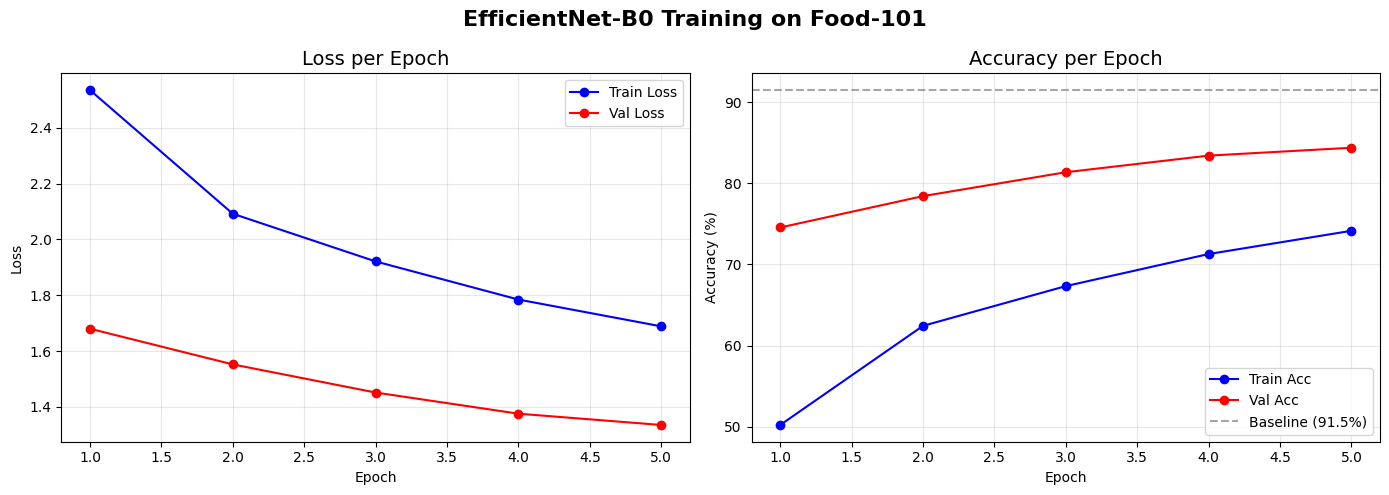

Saved: training_curves.png


In [8]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'],   'r-o', label='Val Loss')
axes[0].set_title('Loss per Epoch', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], 'b-o', label='Train Acc')
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']],   'r-o', label='Val Acc')
axes[1].axhline(y=91.5, color='gray', linestyle='--', alpha=0.7, label='Baseline (91.5%)')
axes[1].set_title('Accuracy per Epoch', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('EfficientNet-B0 Training on Food-101', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

## 7. Evaluation — Best Model

In [9]:
# Load best weights
model.load_state_dict(torch.load('models/best_model.pth', map_location=device))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

overall_acc = (all_preds == all_labels).mean() * 100
print(f'Overall Validation Accuracy: {overall_acc:.2f}%')
print(f'Baseline (preliminary):       91.50%')
print(f'Improvement:                  {overall_acc - 91.5:+.2f}%')

Overall Validation Accuracy: 84.39%
Baseline (preliminary):       91.50%
Improvement:                  -7.11%


In [10]:
class_names = train_dataset.classes

report = classification_report(
    all_labels, all_preds,
    target_names=class_names,
    digits=4
)
print('Classification Report:')
print(report)

Classification Report:
                         precision    recall  f1-score   support

              apple_pie     0.6800    0.6800    0.6800       250
         baby_back_ribs     0.8525    0.8320    0.8421       250
                baklava     0.8884    0.8920    0.8902       250
         beef_carpaccio     0.9057    0.8840    0.8947       250
           beef_tartare     0.7769    0.8080    0.7922       250
             beet_salad     0.7403    0.7640    0.7520       250
               beignets     0.8960    0.8960    0.8960       250
               bibimbap     0.9277    0.9240    0.9259       250
          bread_pudding     0.6511    0.6120    0.6309       250
      breakfast_burrito     0.7433    0.7760    0.7593       250
             bruschetta     0.7826    0.7200    0.7500       250
           caesar_salad     0.8487    0.9200    0.8829       250
                cannoli     0.8664    0.9080    0.8867       250
          caprese_salad     0.7986    0.9040    0.8480       250
 

## 8. Confusion Matrix — Top Misclassified Classes

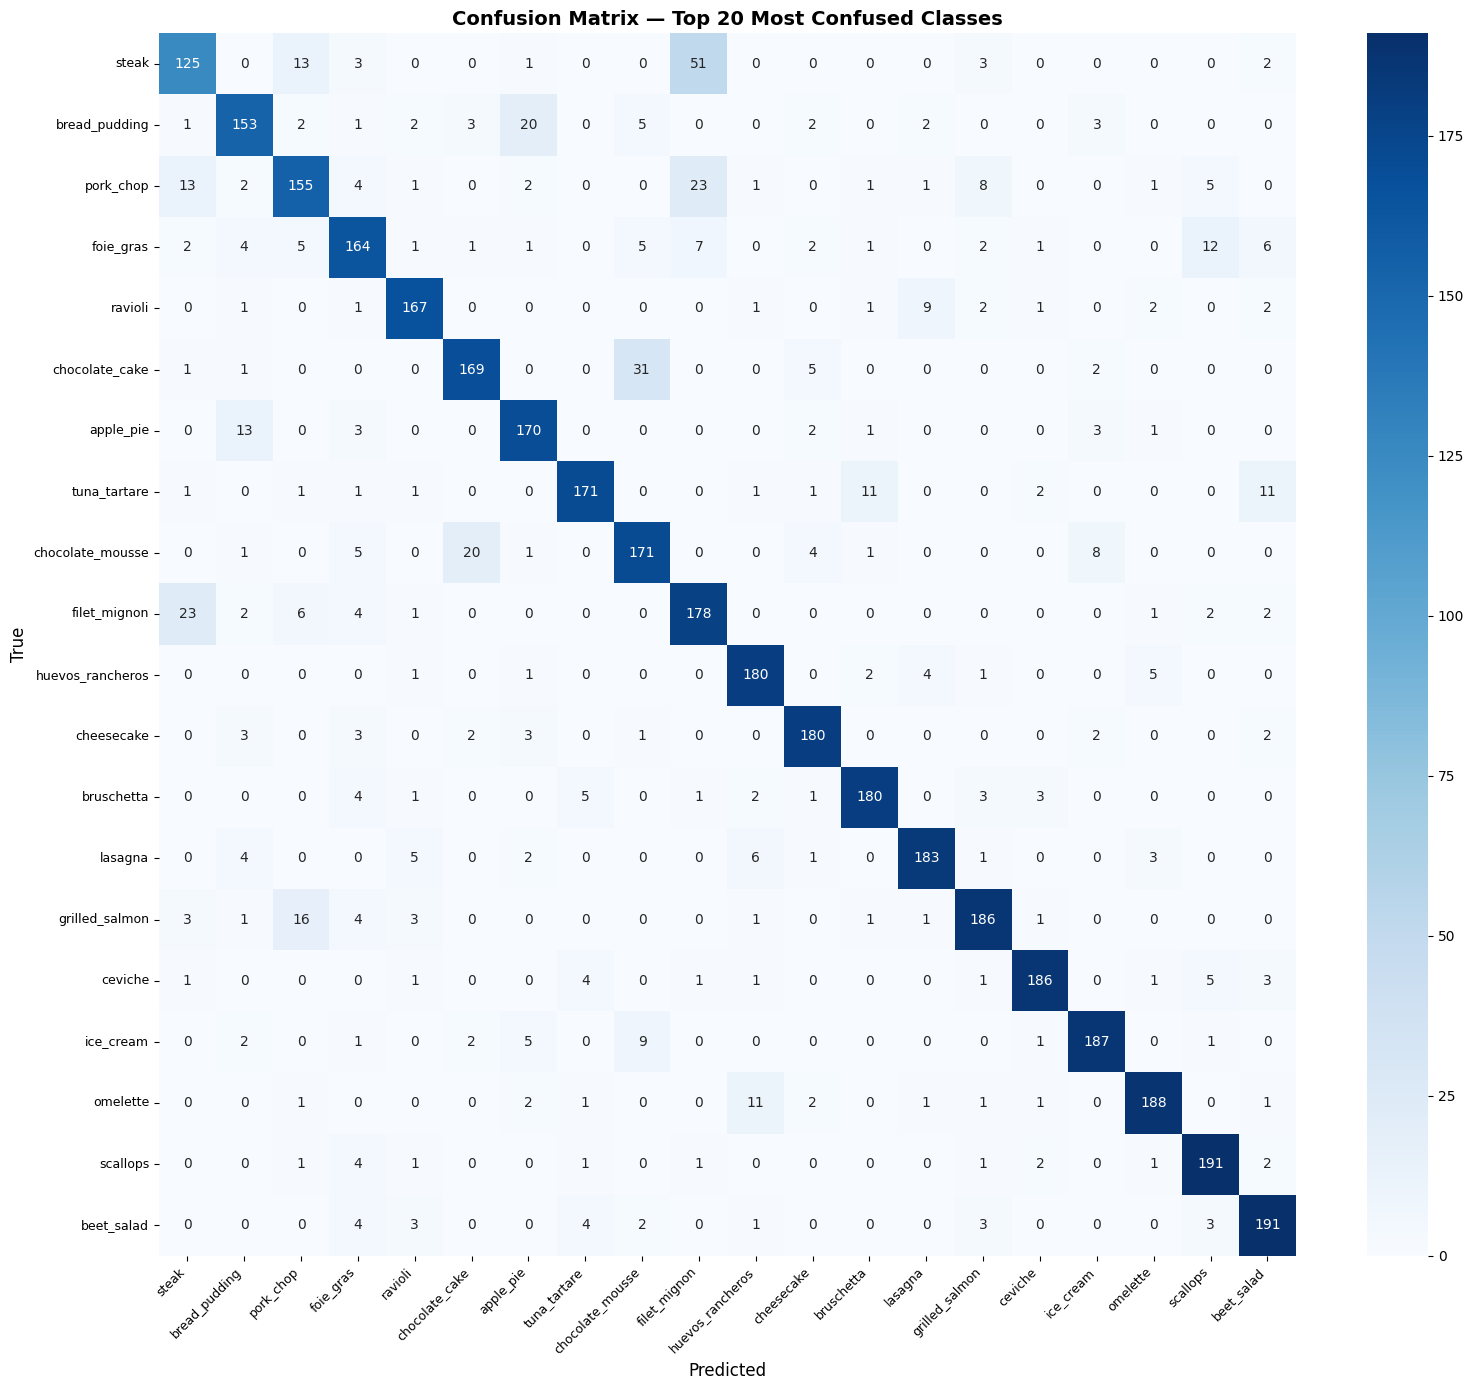

Saved: confusion_matrix.png


In [11]:
cm = confusion_matrix(all_labels, all_preds)

# Find top 15 most confused class pairs (off diagonal with highest counts)
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)

# Get per class error counts to find worst 20 classes
per_class_errors = cm_copy.sum(axis=1)
top20_idx = np.argsort(per_class_errors)[::-1][:20]
top20_names = [class_names[i] for i in top20_idx]

cm_top20 = cm[np.ix_(top20_idx, top20_idx)]

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    cm_top20,
    annot=True, fmt='d',
    xticklabels=top20_names,
    yticklabels=top20_names,
    cmap='Blues',
    ax=ax
)
ax.set_title('Confusion Matrix — Top 20 Most Confused Classes', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

## 9. Results Summary

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_macro = precision_score(all_labels, all_preds, average='macro') * 100
recall_macro    = recall_score(all_labels,    all_preds, average='macro') * 100
f1_macro        = f1_score(all_labels,        all_preds, average='macro') * 100
f1_weighted     = f1_score(all_labels,        all_preds, average='weighted') * 100

print('=' * 45)
print('       FINAL EVALUATION RESULTS')
print('=' * 45)
print(f'  Model:              EfficientNet-B0')
print(f'  Dataset:            Food-101')
print(f'  Epochs trained:     {NUM_EPOCHS}')
print(f'  Batch size:         {BATCH_SIZE}')
print(f'  Optimizer:          AdamW')
print('-' * 45)
print(f'  Accuracy:           {overall_acc:.2f}%')
print(f'  Precision (macro):  {precision_macro:.2f}%')
print(f'  Recall (macro):     {recall_macro:.2f}%')
print(f'  F1 Score (macro):   {f1_macro:.2f}%')
print(f'  F1 Score (weighted):{f1_weighted:.2f}%')
print('-' * 45)
print(f'  Baseline accuracy:  91.50%')
print(f'  Improvement:        {overall_acc - 91.5:+.2f}%')
print('=' * 45)

# Verify model is saved and loadable
test_load = torch.load('models/best_model.pth', map_location='cpu')
print(f'\nmodels/best_model.pth saved and loadable ({len(test_load)} weight tensors)')

       FINAL EVALUATION RESULTS
  Model:              EfficientNet-B0
  Dataset:            Food-101
  Epochs trained:     5
  Batch size:         64
  Optimizer:          AdamW
---------------------------------------------
  Accuracy:           84.39%
  Precision (macro):  84.39%
  Recall (macro):     84.39%
  F1 Score (macro):   84.31%
  F1 Score (weighted):84.31%
---------------------------------------------
  Baseline accuracy:  91.50%
  Improvement:        -7.11%

models/best_model.pth saved and loadable (360 weight tensors)


## 10. Analysis & Discussion

### Model Performance

EfficientNet-B0 was chosen as the final model for this project based on both performance and efficiency. This matters for our use case since the trained weights need to be loaded into the prediction pipeline and eventually a web interface.

### Training Observations

- **Overfitting prevention**: Data augmentation (random crops, horizontal flips, color jitter) and label smoothing (0.1) used to help the model generalize.
- **Fine tuning strategy**: The last two feature blocks were unfrozen in addition to the classifier head, which allowed the model to adapt higher level feature representations to food specific patterns.
- **Scheduler**: CosineAnnealingLR smoothly decays the learning rate over training, which helped stabilize convergence.

### Confusion Matrix Insights

The top misclassified classes tend to be visually similar food categories like steak and filet mignon, or noodle dishes. This is expected, highlighting the difficulty of fine grained food classification from 2D images alone.

### Next Steps

The saved `models/best_model.pth` will be used by:
- `src/model.py` — prediction pipeline (Issue #1)
- `src/app.py` — Streamlit web interface (Issue #3)